#### __Import Required Libraries__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries imported successfully!')

✓ Libraries imported successfully!


#### __Load the Dataset__

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print('✓ Dataset loaded successfully!')
print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')

✓ Dataset loaded successfully!
Train shape: (2000, 21)
Test shape : (1000, 21)


### ___STEP 2: EXPLORATORY DATA ANALYSIS (EDA) AND PREPROCESSING___

#### __2.1 Basic Dataset Information__

In [3]:
print('First 5 rows of training data:')
print('='*80)
train_df.head()

First 5 rows of training data:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
print('Dataset Information:')
print('='*80)
train_df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   

In [5]:
print('Statistical Summary:')
print('='*80)
train_df.describe()

Statistical Summary:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


#### __2.2 Understanding Features__

**Feature Descriptions:**
- **battery_power**: Total energy a battery can store in mAh
- **blue**: Has Bluetooth (0/1)
- **clock_speed**: Speed of microprocessor
- **dual_sim**: Has dual SIM support (0/1)
- **fc**: Front camera megapixels
- **four_g**: Has 4G (0/1)
- **int_memory**: Internal memory in GB
- **m_dep**: Mobile depth in cm
- **mobile_wt**: Weight of mobile phone
- **n_cores**: Number of processor cores
- **pc**: Primary camera megapixels
- **px_height / px_width**: Pixel resolution
- **ram**: RAM in MB
- **sc_h / sc_w**: Screen height and width in cm
- **talk_time**: Battery talk time in hours
- **three_g**: Has 3G (0/1)
- **touch_screen**: Has touchscreen (0/1)
- **wifi**: Has WiFi (0/1)
- **price_range**: Target — 0=Low, 1=Medium, 2=High, 3=Very High

In [6]:
cat_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
print('Unique values in binary categorical columns:')
print('='*60)
for col in cat_cols:
    print(f'{col:15s}: {sorted(train_df[col].unique())}')

Unique values in binary categorical columns:
blue           : [0, 1]
dual_sim       : [0, 1]
four_g         : [0, 1]
three_g        : [0, 1]
touch_screen   : [0, 1]
wifi           : [0, 1]


#### __2.3 Target Variable Analysis__

Target Variable (price_range) Distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


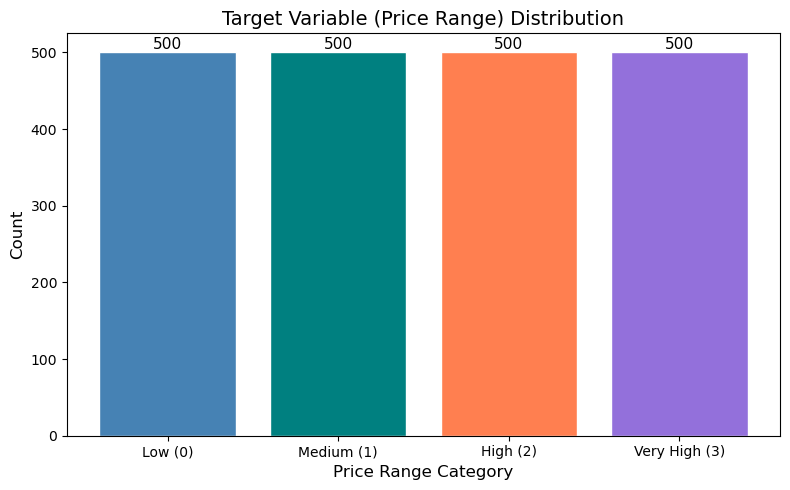

In [7]:
print('Target Variable (price_range) Distribution:')
print('='*80)
print(train_df['price_range'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
counts = train_df['price_range'].value_counts().sort_index()
bars = ax.bar(['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)'],
              counts.values, color=['steelblue','teal','coral','mediumpurple'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontsize=11)
ax.set_xlabel('Price Range Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Target Variable (Price Range) Distribution', fontsize=14)
plt.tight_layout()
plt.show()

#### __2.4 Missing Values Analysis__

In [8]:
print('Missing Values Analysis:')
print()
missing = train_df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found in any column! ✓')
else:
    print(missing[missing > 0])

Missing Values Analysis:

No missing values found in any column! ✓


#### __2.5 Numerical Features Distribution__

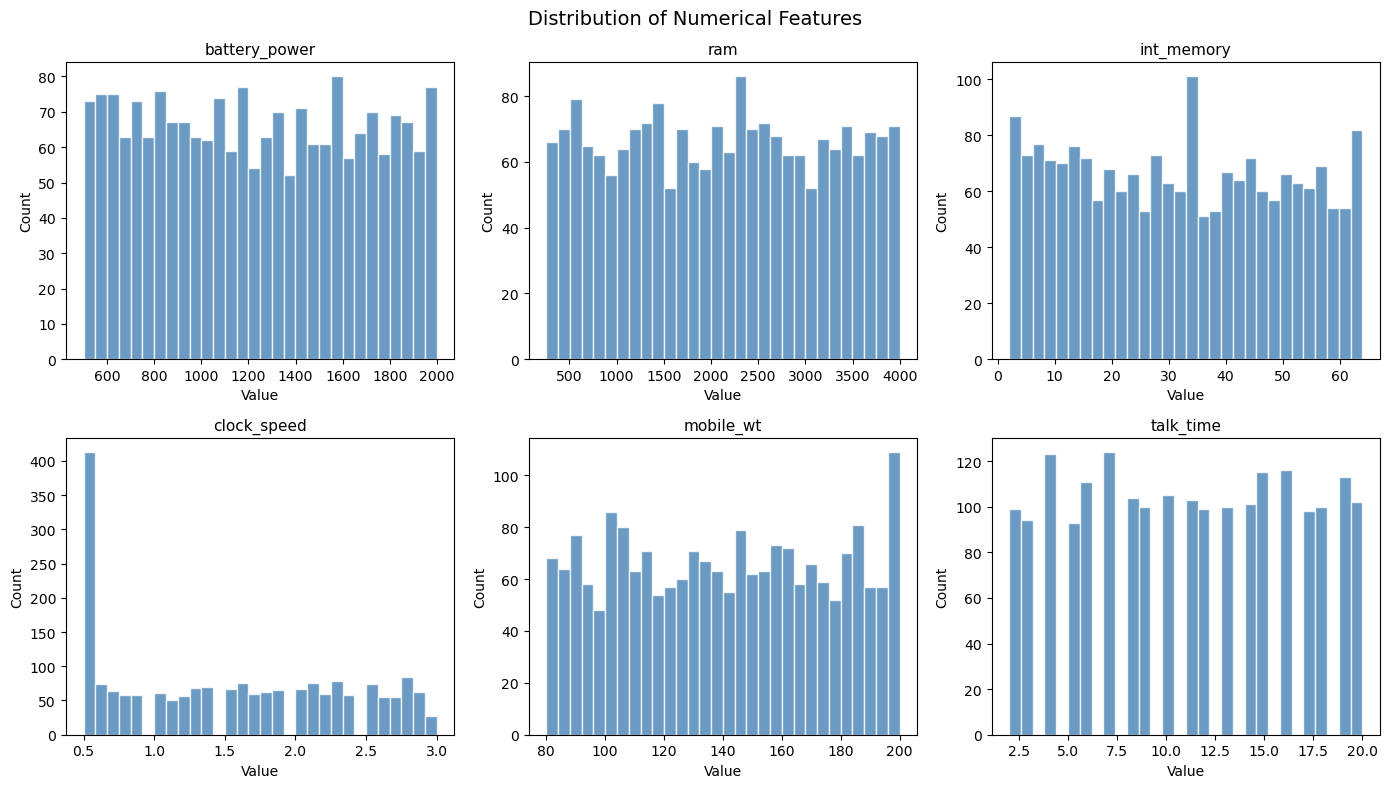

In [9]:
num_feats = ['battery_power', 'ram', 'int_memory', 'clock_speed', 'mobile_wt', 'talk_time']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, feat in enumerate(num_feats):
    ax = axes[i//3][i%3]
    ax.hist(train_df[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

#### __2.6 Categorical Features vs Target__

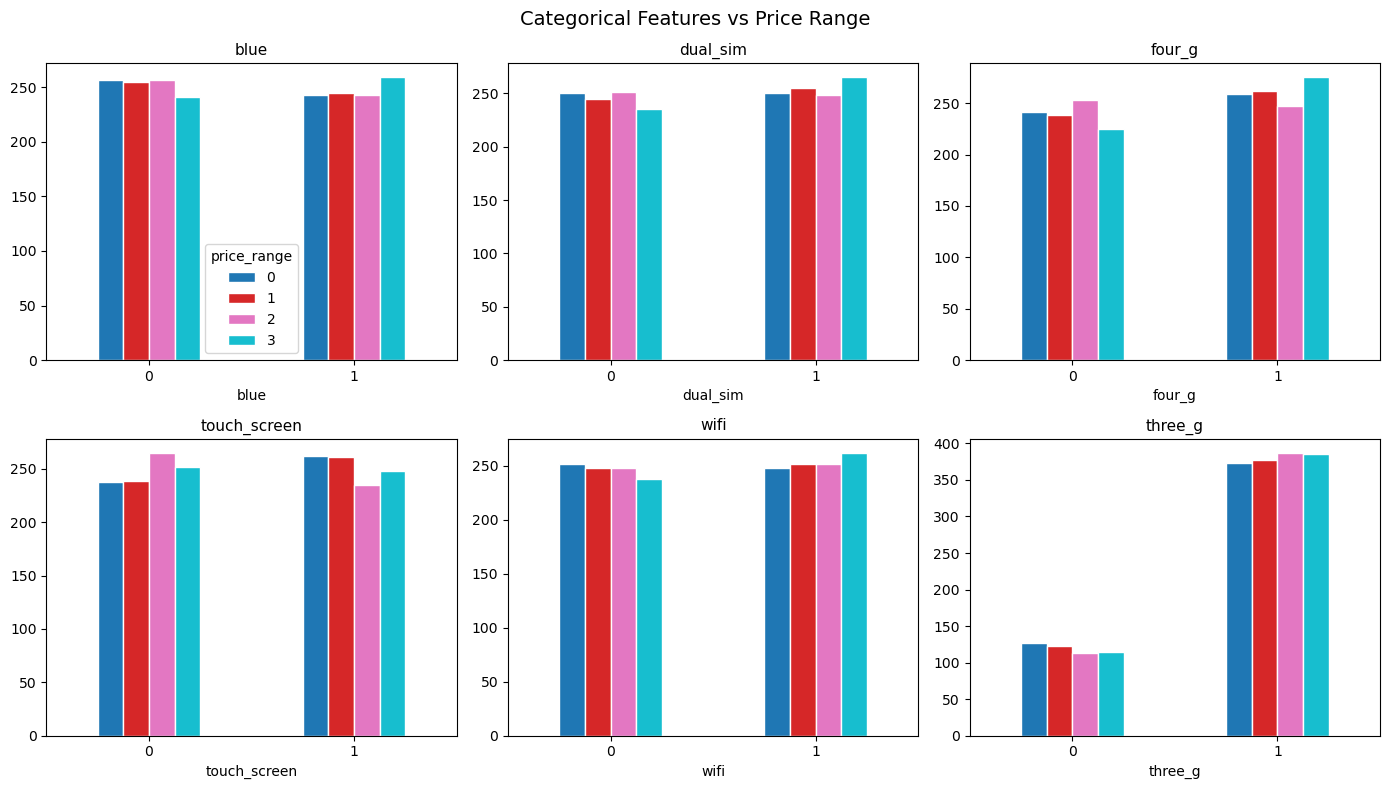

In [10]:
cat_feats = ['blue', 'dual_sim', 'four_g', 'touch_screen', 'wifi', 'three_g']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, feat in enumerate(cat_feats):
    ax = axes[i//3][i%3]
    ct = train_df.groupby([feat, 'price_range']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', legend=(i==0))
    ax.set_title(feat, fontsize=11)
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Categorical Features vs Price Range', fontsize=14)
plt.tight_layout()
plt.show()

#### __2.7 Correlation Analysis__

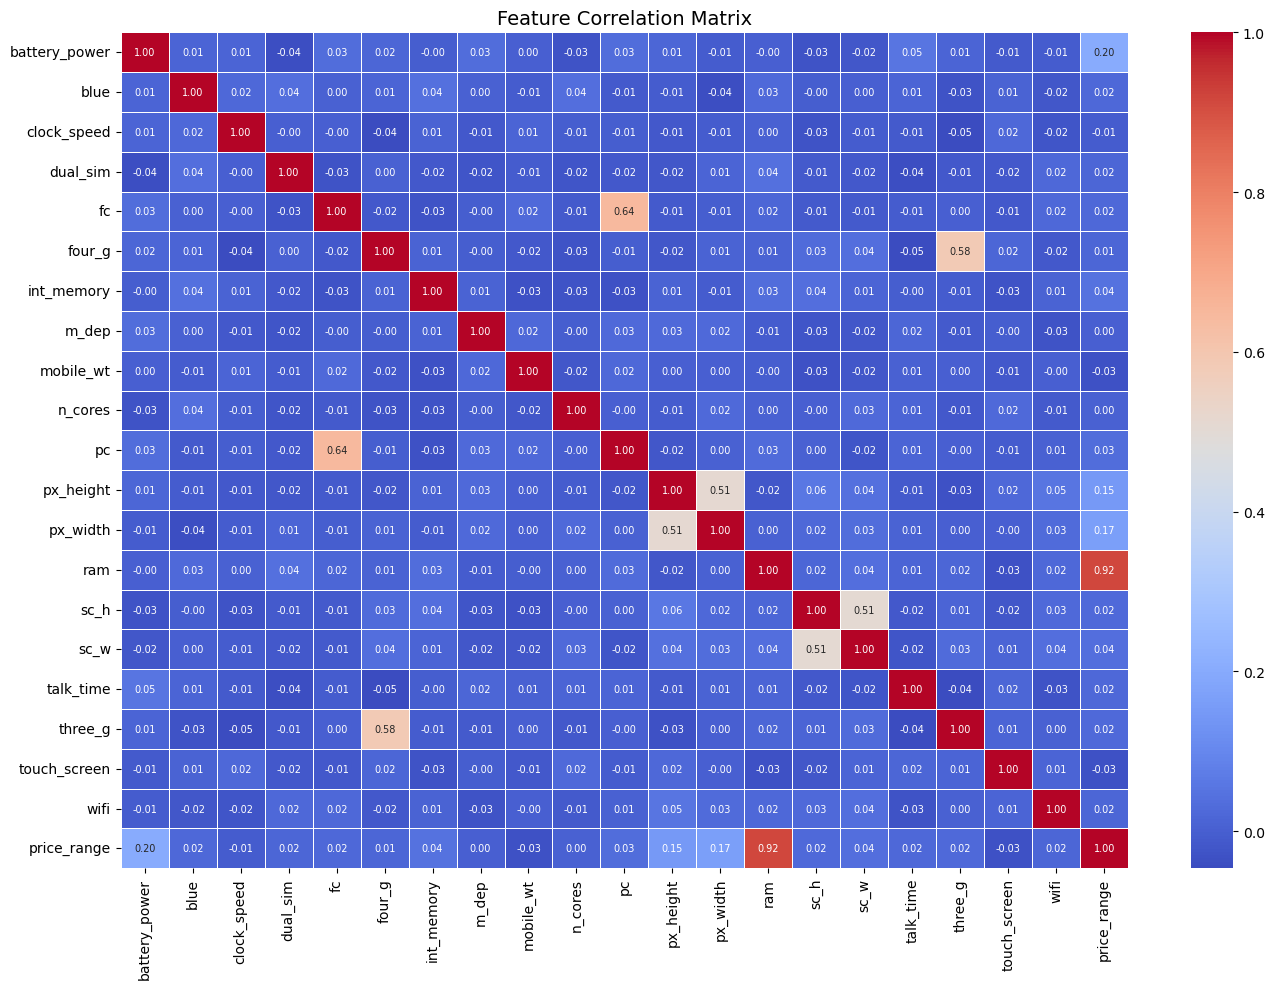

In [11]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = train_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

#### __2.8 Data Preprocessing__

In [12]:
target_col   = 'price_range'
feature_cols = [c for c in train_df.columns if c != target_col]

X            = train_df[feature_cols]
y            = train_df[target_col]
X_test_final = test_df[feature_cols]

print(f'Features used    : {len(feature_cols)}')
print(f'Training samples : {X.shape[0]}')
print(f'Test samples     : {X_test_final.shape[0]}')

Features used    : 20
Training samples : 2000
Test samples     : 1000


#### __2.9 Split & Scale Features__

In [13]:
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Dataset Split:')
print('='*80)
print(f'Training samples  : {X_tr.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')

Dataset Split:
Training samples  : 1600
Validation samples: 400



### ___STEP 3: TRAIN CLASSIFICATION MODELS TO PREDICT MOBILE PRICE RANGE___

#### __3.1 Create Train-Validation Split__

In [14]:
print(f'X_tr  shape : {X_tr.shape}')
print(f'X_val shape : {X_val.shape}')
print(f'y_tr  shape : {y_tr.shape}')
print(f'y_val shape : {y_val.shape}')

X_tr  shape : (1600, 20)
X_val shape : (400, 20)
y_tr  shape : (1600,)
y_val shape : (400,)


#### __3.2 Train Multiple Models__

In [15]:
print('Training Multiple Classification Models...')
print('='*80)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    tr_acc  = accuracy_score(y_tr,  model.predict(X_tr))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'model': model, 'train_acc': tr_acc, 'val_acc': val_acc}
    print(f'{name:22s} - Train: {tr_acc:.4f} | Val: {val_acc:.4f}')

Training Multiple Classification Models...
Logistic Regression    - Train: 0.9756 | Val: 0.9775
Random Forest          - Train: 1.0000 | Val: 0.8925
Gradient Boosting      - Train: 0.9994 | Val: 0.9050


#### __3.3 Compare Model Performance__

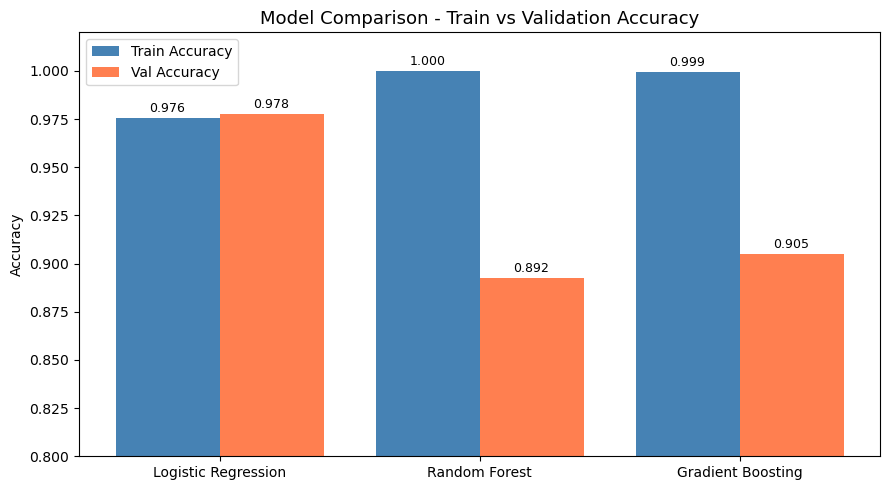

Best Model: Logistic Regression (Val Accuracy: 0.9775)


In [16]:
names    = list(results.keys())
tr_accs  = [results[n]['train_acc'] for n in names]
val_accs = [results[n]['val_acc']   for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names))
ax.bar(x-0.2, tr_accs,  0.4, label='Train Accuracy', color='steelblue')
ax.bar(x+0.2, val_accs, 0.4, label='Val Accuracy',   color='coral')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.8, 1.02)
ax.set_title('Model Comparison - Train vs Validation Accuracy', fontsize=13)
ax.legend()
for i,(tr,va) in enumerate(zip(tr_accs,val_accs)):
    ax.text(i-0.2, tr+0.003, f'{tr:.3f}', ha='center', fontsize=9)
    ax.text(i+0.2, va+0.003, f'{va:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

best_name  = max(results, key=lambda k: results[k]['val_acc'])
best_model = results[best_name]['model']
print(f'Best Model: {best_name} (Val Accuracy: {results[best_name]["val_acc"]:.4f})')


### __STEP 4: EVALUATE AND IMPROVE MODEL PERFORMANCE__

#### __4.1 Detailed Evaluation of Best Model__

In [17]:
print(f'Detailed Evaluation of {best_name}')
print('='*80)
y_pred_val = best_model.predict(X_val)
print(classification_report(y_val, y_pred_val, target_names=['Low','Medium','High','Very High']))

Detailed Evaluation of Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      0.97      0.99       105
      Medium       0.95      1.00      0.97        91
        High       0.99      0.95      0.97        92
   Very High       0.97      0.99      0.98       112

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



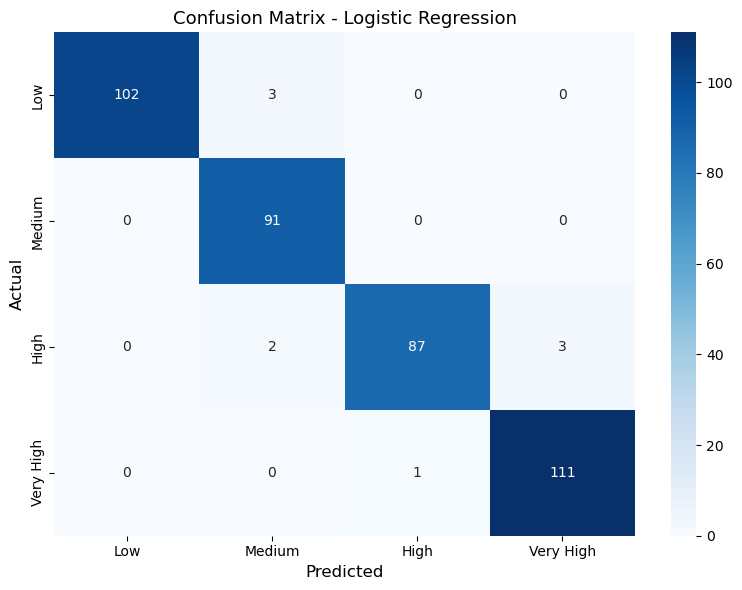

In [18]:
cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low','Medium','High','Very High'],
            yticklabels=['Low','Medium','High','Very High'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

#### __4.3 Hyperparameter Tuning (Optional - Improve Performance)__

In [19]:
print('Hyperparameter Tuning:')
print('='*80)
print('Note: This may take a few minutes...\n')

param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
gs = GridSearchCV(RandomForestClassifier(random_state=42),
                  param_grid, cv=3, scoring='accuracy', n_jobs=-1)
gs.fit(X_tr, y_tr)
print(f'Best params  : {gs.best_params_}')
print(f'Best CV score: {gs.best_score_:.4f}')

Hyperparameter Tuning:
Note: This may take a few minutes...

Best params  : {'max_depth': None, 'n_estimators': 200}
Best CV score: 0.8656


#### __4.4 Final Model Training on Full Dataset__

In [20]:
print('Training Final Model on Complete Training Data:')
print('='*80)
final_model = gs.best_estimator_
final_model.fit(X_scaled, y)
print('✓ Final model trained successfully!')

Training Final Model on Complete Training Data:
✓ Final model trained successfully!


#### __4.5 Make Predictions on Test Set__

In [21]:
print('Making Predictions on Test Set:')
print('='*80)
test_predictions = final_model.predict(X_test_scaled)
print(f'✓ Predictions generated for {len(test_predictions)} test samples')

Making Predictions on Test Set:
✓ Predictions generated for 1000 test samples


#### __4.6 Create Submission File__

In [22]:
print('Creating Submission File:')
print('='*80)
submission_df = pd.DataFrame({
    'id': range(1, len(test_predictions)+1),
    'price_range': test_predictions
})
submission_df.to_csv('submission.csv', index=False)
print('✓ submission.csv saved successfully!')
print(submission_df.head(3).to_string(index=False))

Creating Submission File:
✓ submission.csv saved successfully!
 id  price_range
  1            3
  2            3
  3            2
